# 5CharCNN Trainer

## Imports

In [1]:
# --- Standard library ---
from pathlib import Path
import sys
import json
from datetime import datetime

# Locate repository root so that 'src' modules can be imported
REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Repository root found at: {REPO_ROOT}")

# --- Third-party ---
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# --- Local imports ---
from src.dataset.dataloader import create_dataloaders
from src.models.FiveCharCNN import FiveCharCaptchaCNN
from src.training.engine import compute_metrics, unpack_batch, train_one_epoch, validate_one_epoch
from src.training.setup import build_training_state

Repository root found at: /Users/marc/Documents/VS-Code Projects/captcha-ai


## Configure Settings

In [2]:
# =========================
# Config
# =========================

# Define path for saving runs and outputs
EXPERIMENTS_DIR = REPO_ROOT / "experiments" / "Debugging"

# Create a new folder
RUN_NAME = f"test_run_{datetime.now().strftime('%Y%m%d_%H%M')}"
RUN_DIR = EXPERIMENTS_DIR / RUN_NAME
RUN_DIR.mkdir(parents=True, exist_ok=True)

# Define paths for saving models, history, and plots
BEST_MODEL_PATH = RUN_DIR / "best_model.pt"
LAST_MODEL_PATH = RUN_DIR / "last_model.pt"
HISTORY_PATH = RUN_DIR / "training_history.json"
CONFIG_PATH = RUN_DIR / "config.json"
CURVES_PATH = RUN_DIR / "training_curves.png"


# =========================
# Core task config
# =========================

NUM_CHAR_CLASSES = 10
LABEL_LENGTH = 5


# =========================
# Training config
# =========================

BATCH_SIZE = 50
NUM_EPOCHS = 15
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4

# =========================
# Dataset split config
# =========================

TRAIN_RATIO = 0.75
VAL_RATIO = 0.15
TEST_RATIO = 0.1

RANDOM_SEED = 69
TRAINING = True
SHUFFLE_TRAIN = True

NUM_WORKERS = 0
PIN_MEMORY = False
DROP_LAST = False

SUBSET_FRACTION = 1.0
RETURN_FILENAMES = False


# =========================
# Debug & Performance config
# =========================

SAVE_PLOTS = True
PRINT_BATCH_SHAPES = True


# =========================
# Device config
# =========================

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Using device: {DEVICE}")
print(f"Run directory: {RUN_DIR}")

Using device: mps
Run directory: /Users/marc/Documents/VS-Code Projects/captcha-ai/experiments/Debugging/test_run_20260401_1644


## Save Run Configurations

In [3]:
CONFIG = {
    "num_char_classes": NUM_CHAR_CLASSES,
    "label_length": LABEL_LENGTH,
    
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "learning_rate": LEARNING_RATE,
    
    "train_ratio": TRAIN_RATIO,
    "val_ratio": VAL_RATIO,
    "test_ratio": TEST_RATIO,
    "random_seed": RANDOM_SEED,
    
    "shuffle_train": SHUFFLE_TRAIN,
    "num_workers": NUM_WORKERS,
    "pin_memory": PIN_MEMORY,
    "drop_last": DROP_LAST,
    
    "subset_fraction": SUBSET_FRACTION,
    "return_filenames": RETURN_FILENAMES,

    "device": str(DEVICE),
}


with open(CONFIG_PATH, "w") as f:
    json.dump(CONFIG, f, indent=4)

## Create Data loaders

In [4]:
# =========================
# Create dataloaders
# =========================

# Create train/validation/test dataloaders and character mappings
train_loader, val_loader, test_loader, char_to_idx, idx_to_char = create_dataloaders(
    batch_size=BATCH_SIZE,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO,
    random_seed=RANDOM_SEED,
    training=TRAINING,
    shuffle_train=SHUFFLE_TRAIN,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=DROP_LAST,
    subset_fraction=SUBSET_FRACTION,
    return_filenames=RETURN_FILENAMES,
)
print("Loaders created successfully.")

Loaders created successfully.


In [5]:
model, criterion, optimizer, history = build_training_state(
    num_char_classes=NUM_CHAR_CLASSES,
    label_length=LABEL_LENGTH,
    device=DEVICE,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

## Training Loop

In [6]:
# =========================
# Full training loop
# =========================

best_val_seq_acc = -1.0

for epoch in range(NUM_EPOCHS):
    train_loss, train_char_acc, train_seq_acc = train_one_epoch(
    model=model,
    loader=train_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=DEVICE,
    num_char_classes=NUM_CHAR_CLASSES,
)

    val_loss, val_char_acc, val_seq_acc, val_pos_accs = validate_one_epoch(
    model=model,
    loader=val_loader,
    criterion=criterion,
    device=DEVICE,
    num_char_classes=NUM_CHAR_CLASSES,
    label_length=LABEL_LENGTH,
)

    # Save metrics
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_char_acc"].append(train_char_acc)
    history["val_char_acc"].append(val_char_acc)
    history["train_seq_acc"].append(train_seq_acc)
    history["val_seq_acc"].append(val_seq_acc)

    for i in range(LABEL_LENGTH):
        history[f"val_pos_acc_{i}"].append(val_pos_accs[i])

    # Epoch panel
    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"Train Char Acc: {train_char_acc:.4f} | Val Char Acc: {val_char_acc:.4f}")
    print(f"Train Seq Acc:  {train_seq_acc:.4f} | Val Seq Acc:  {val_seq_acc:.4f}")
    print("Val Pos Accs:", [f"{acc:.4f}" for acc in val_pos_accs])

    # Save best model
    if val_seq_acc > best_val_seq_acc:
        best_val_seq_acc = val_seq_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"New best model saved to: {BEST_MODEL_PATH}")

# Save last model
torch.save(model.state_dict(), LAST_MODEL_PATH)
print(f"\nLast model saved to: {LAST_MODEL_PATH}")

# =========================
# Save training history
# =========================

with open(HISTORY_PATH, "w") as f:
    json.dump(history, f, indent=4)

print(f"Training history saved to: {HISTORY_PATH}")

[0/790] Loss: 2.2991 | Char Acc: 0.0920 | Seq Acc: 0.0000 | Time: 1.8s
[100/790] Loss: 2.1083 | Char Acc: 0.1840 | Seq Acc: 0.0000 | Time: 9.7s
[200/790] Loss: 1.6016 | Char Acc: 0.4040 | Seq Acc: 0.0000 | Time: 17.6s
[300/790] Loss: 1.3133 | Char Acc: 0.5000 | Seq Acc: 0.0600 | Time: 25.7s
[400/790] Loss: 0.9933 | Char Acc: 0.6480 | Seq Acc: 0.1400 | Time: 33.8s
[500/790] Loss: 0.6874 | Char Acc: 0.7760 | Seq Acc: 0.2800 | Time: 41.8s
[600/790] Loss: 0.5962 | Char Acc: 0.8200 | Seq Acc: 0.3400 | Time: 49.8s
[700/790] Loss: 0.4341 | Char Acc: 0.8720 | Seq Acc: 0.5200 | Time: 57.8s

Epoch [1/15]
Train Loss: 1.1365 | Val Loss: 0.3963
Train Char Acc: 0.5861 | Val Char Acc: 0.8751
Train Seq Acc:  0.1895 | Val Seq Acc:  0.5158
Val Pos Accs: ['0.9472', '0.8663', '0.7924', '0.8152', '0.9547']
New best model saved to: /Users/marc/Documents/VS-Code Projects/captcha-ai/experiments/Debugging/test_run_20260401_1644/best_model.pt
[0/790] Loss: 0.3855 | Char Acc: 0.8800 | Seq Acc: 0.5800 | Time: 0.1

## Plot Curves

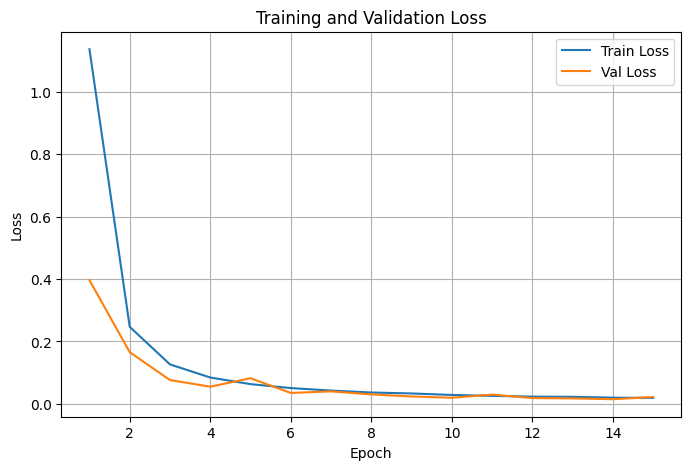

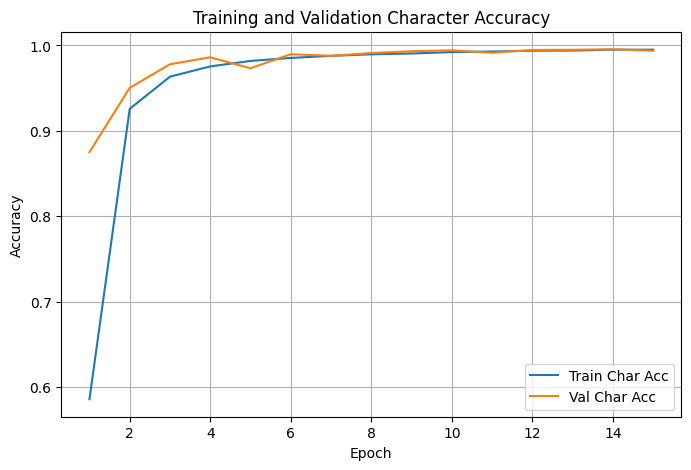

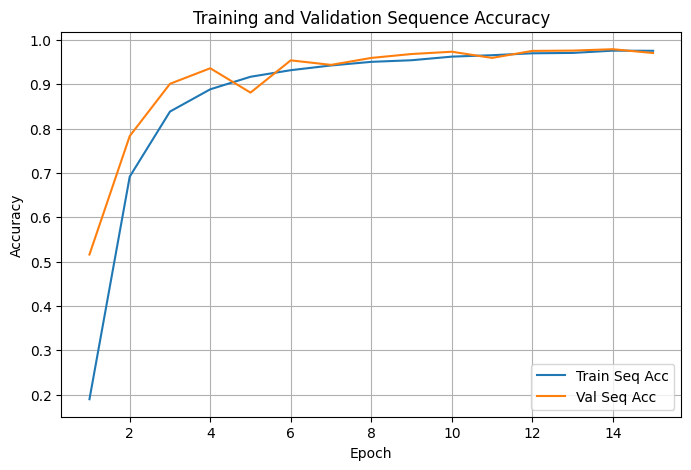

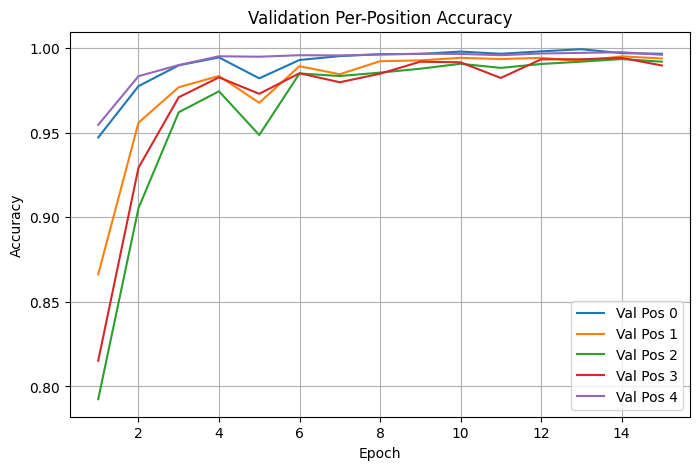

In [7]:
# =========================
# Plot training curves
# =========================

epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
if SAVE_PLOTS:
    plt.savefig(CURVES_PATH.with_name("loss_" + CURVES_PATH.name), bbox_inches="tight")
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_char_acc"], label="Train Char Acc")
plt.plot(epochs, history["val_char_acc"], label="Val Char Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Character Accuracy")
plt.legend()
plt.grid(True)
if SAVE_PLOTS:
    plt.savefig(CURVES_PATH.with_name("char_acc_" + CURVES_PATH.name), bbox_inches="tight")
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_seq_acc"], label="Train Seq Acc")
plt.plot(epochs, history["val_seq_acc"], label="Val Seq Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Sequence Accuracy")
plt.legend()
plt.grid(True)
if SAVE_PLOTS:
    plt.savefig(CURVES_PATH.with_name("seq_acc_" + CURVES_PATH.name), bbox_inches="tight")
plt.show()


plt.figure(figsize=(8, 5))
for i in range(LABEL_LENGTH):
    plt.plot(epochs, history[f"val_pos_acc_{i}"], label=f"Val Pos {i}")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Per-Position Accuracy")
plt.legend()
plt.grid(True)
if SAVE_PLOTS:
    plt.savefig(CURVES_PATH.with_name("val_pos_acc_" + CURVES_PATH.name), bbox_inches="tight")
plt.show()

## Inspect Predictions

In [11]:
# =========================
# Inspect validation predictions
# =========================

model.eval()

num_examples_to_show = 10

with torch.no_grad():
    batch = next(iter(test_loader))
    images, labels, filenames = unpack_batch(batch)

    images = images.to(DEVICE)
    labels = labels.to(DEVICE)

    outputs = model(images)
    preds = outputs.argmax(dim=-1)

labels = labels.cpu()
preds = preds.cpu()

print("\nValidation predictions preview\n")

for i in range(min(num_examples_to_show, images.size(0))):
    true_string = "".join(idx_to_char[int(x)] for x in labels[i])
    pred_string = "".join(idx_to_char[int(x)] for x in preds[i])

    print(f"Example {i+1}")
    print(f"True: {true_string}")
    print(f"Pred: {pred_string}")

    if filenames is not None:
        print(f"File: {filenames[i]}")

    print("-" * 30)


Validation predictions preview

Example 1
True: 97189
Pred: 97189
------------------------------
Example 2
True: 12203
Pred: 12203
------------------------------
Example 3
True: 71336
Pred: 71336
------------------------------
Example 4
True: 81998
Pred: 81998
------------------------------
Example 5
True: 20099
Pred: 20099
------------------------------
Example 6
True: 91094
Pred: 91094
------------------------------
Example 7
True: 93302
Pred: 93302
------------------------------
Example 8
True: 20007
Pred: 20007
------------------------------
Example 9
True: 33646
Pred: 33646
------------------------------
Example 10
True: 21633
Pred: 21633
------------------------------


## (Optional) manual visual inspection

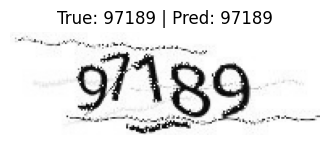

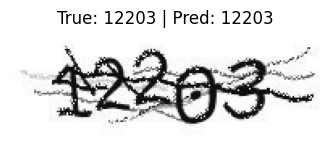

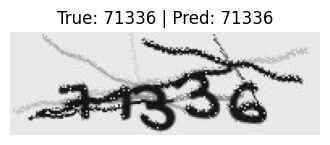

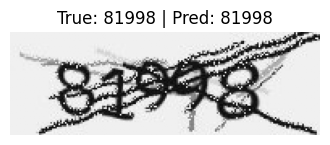

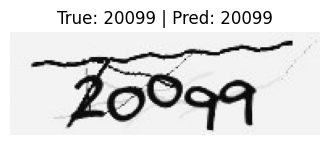

In [12]:
# =========================
# Show validation images with true/pred labels
# =========================

num_images_to_show = 5

for i in range(min(num_images_to_show, images.size(0))):
    img_np = images[i].detach().cpu().squeeze().numpy()
    true_string = "".join(idx_to_char[int(x)] for x in labels[i])
    pred_string = "".join(idx_to_char[int(x)] for x in preds[i])

    plt.figure(figsize=(4, 2))
    plt.imshow(img_np, cmap="gray")
    plt.title(f"True: {true_string} | Pred: {pred_string}")
    plt.axis("off")
    plt.show()